In [273]:
import matplotlib.pyplot as plt
import numpy as np
import json

import math
from collections import deque
from typing import List, Tuple, Optional

In [274]:
class OpenAreaExplorer:
    """
    Simple and robust 360° open-area explorer.

    Principle
    ---------
    1. Collect (angle, distance)
    2. Keep only open points
    3. Group neighboring angles into sectors
    4. Select the widest sector
    5. Inside that sector:
         choose the point with maximum distance

    Designed for noisy IMU scans with irregular gaps.
    """

    def __init__(
        self,
        open_distance_threshold: float = 0.25,
        min_sector_size_deg: float = 20.0,
        max_angle_gap_deg: float = 30.0,
        filter_window_size: int = 3,
    ):

        # Raw samples
        self.samples: List[Tuple[float, float]] = []

        # Threshold to consider area open
        self.open_distance_threshold = (
            open_distance_threshold
        )

        # Minimum valid sector width
        self.min_sector_size_rad = math.radians(
            min_sector_size_deg
        )

        # Maximum gap between points
        self.max_angle_gap_rad = math.radians(
            max_angle_gap_deg
        )

        # Distance smoothing
        self.front_history = deque(
            maxlen=filter_window_size
        )

        self.best_heading_angle = 0.0

    # =====================================================
    # ANGLES
    # =====================================================

    @staticmethod
    def normalize_angle(angle: float) -> float:
        """
        Normalize angle to [-pi, pi]
        """

        while angle > math.pi:
            angle -= 2 * math.pi

        while angle < -math.pi:
            angle += 2 * math.pi

        return angle

    @staticmethod
    def angular_distance(a: float, b: float) -> float:
        """
        Smallest circular angular distance
        """

        diff = a - b

        return math.atan2(
            math.sin(diff),
            math.cos(diff)
        )

    # =====================================================
    # FILTER
    # =====================================================

    def filter_distance(
        self,
        distance: float
    ) -> float:

        self.front_history.append(distance)

        return (
            sum(self.front_history) /
            len(self.front_history)
        )

    # =====================================================
    # INPUT
    # =====================================================

    def add_sample(
        self,
        imu_angle: float,
        front_distance: float,
    ):
        """
        Add scan sample
        """

        imu_angle = self.normalize_angle(
            imu_angle
        )

        filtered_distance = self.filter_distance(
            front_distance
        )

        self.samples.append(
            (
                imu_angle,
                filtered_distance
            )
        )

    # =====================================================
    # DETECT OPEN SECTORS
    # =====================================================

    def _detect_open_sectors(
        self,
        samples
    ):
        """
        Detect continuous open sectors
        """

        open_sectors = []

        current_sector = []

        previous_angle = None

        for angle, distance in samples:

            # Ignore blocked points
            if (
                distance <
                self.open_distance_threshold
            ):

                if current_sector:

                    open_sectors.append(
                        current_sector
                    )

                    current_sector = []

                previous_angle = None

                continue

            # First point
            if previous_angle is None:

                current_sector = [
                    (angle, distance)
                ]

                previous_angle = angle

                continue

            # Circular angular gap
            gap = abs(
                self.angular_distance(
                    angle,
                    previous_angle
                )
            )

            # New sector if gap too large
            if gap > self.max_angle_gap_rad:

                if current_sector:

                    open_sectors.append(
                        current_sector
                    )

                current_sector = [
                    (angle, distance)
                ]

            else:

                current_sector.append(
                    (angle, distance)
                )

            previous_angle = angle

        # Final sector
        if current_sector:

            open_sectors.append(
                current_sector
            )

        return open_sectors

    # =====================================================
    # SECTOR WIDTH
    # =====================================================

    def _sector_width(
        self,
        sector
    ) -> float:
        """
        Compute sector angular width
        """

        if len(sector) < 2:
            return 0.0

        angles = [
            a for a, _ in sector
        ]

        angles = sorted(angles)

        width = 0.0

        for i in range(1, len(angles)):

            width += abs(
                self.angular_distance(
                    angles[i],
                    angles[i - 1]
                )
            )

        return width

    # =====================================================
    # MAIN
    # =====================================================

    def get_best_heading(
        self
    ) -> Optional[float]:
        """
        Compute best escape heading
        """

        if len(self.samples) < 3:
            return None

        # Sort by angle
        samples = sorted(
            self.samples,
            key=lambda x: x[0]
        )

        # Detect sectors
        open_sectors = (
            self._detect_open_sectors(
                samples
            )
        )

        if not open_sectors:
            return None

        # Keep valid sectors
        valid_sectors = []

        for sector in open_sectors:

            width = self._sector_width(
                sector
            )
            print(sector, "width=",width, "deg=",np.rad2deg(width))
            print("##################")

            if (
                width >=
                self.min_sector_size_rad
            ):

                valid_sectors.append(
                    sector
                )

        if not valid_sectors:
            return None

        # Select widest sector
        best_sector = max(
            valid_sectors,
            key=lambda s:
                self._sector_width(s)
        )

        # Inside sector:
        # choose max distance point
        best_angle, _ = max(
            best_sector,
            key=lambda x: x[1]
        )
        
        angles = [
            a for a, _ in best_sector
        ]

        x = sum(math.cos(a) for a in angles)
        y = sum(math.sin(a) for a in angles)

        best_angle = math.atan2(y, x)
        
        print("\n\n\nBest Sector")
        print(best_sector)

        self.best_heading_angle = (
            self.normalize_angle(
                best_angle
            )
        )

        return self.best_heading_angle
        
    def load_data(self, filepath: str):
        """
        Load scan data from a JSON file
        """

        with open(filepath, "r") as f:
            data = json.load(f)

        self.samples = [
            (item["angle"], item["distance"])
            for item in data["samples"]
        ]
        
        self.samples = sorted(self.samples, key=lambda k: k[0])

        self.open_distance_threshold = data.get(
            "open_distance_threshold",
            self.open_distance_threshold
        )

        self.min_sector_size_rad = data.get(
            "min_sector_size_rad",
            self.min_sector_size_rad
        )
        
        
    def plot_scan(self, best_sector=None, best_heading=None):
        """
        Visualisation des scans + secteurs ouverts
        """

        if not self.samples:
            return

        angles = np.array([s[0] for s in self.samples])
        distances = np.array([s[1] for s in self.samples])

        # Conversion en degrés pour affichage plus lisible
        angles_deg = np.degrees(angles)

        plt.figure(figsize=(10, 5))

        # -----------------------------
        # Plot des mesures
        # -----------------------------
        plt.scatter(
            angles_deg,
            distances,
            c="blue",
            label="Mesures front",
        )

        # -----------------------------
        # Seuil open
        # -----------------------------
        plt.axhline(
            self.open_distance_threshold,
            color="red",
            linestyle="--",
            label="Seuil open",
        )

        # -----------------------------
        # Best heading
        # -----------------------------
        if best_heading is not None:
            plt.axvline(
                np.degrees(best_heading),
                color="green",
                linewidth=2,
                label="Best heading",
            )

        plt.xlabel("Angle (deg)")
        plt.ylabel("Distance")
        plt.title("Open Area Explorer - Scan 360°")
        plt.legend()
        plt.grid()

        plt.show()
        
    def plot_polar(self, best_heading=None):
        """
        Visualisation polaire type radar
        """

        if not self.samples:
            return

        angles = np.array([s[0] for s in self.samples])
        distances = np.array([s[1] for s in self.samples])

        plt.figure(figsize=(7, 7))
        ax = plt.subplot(111, projection="polar")

        # -----------------------------
        # Points de mesure
        # -----------------------------
        ax.scatter(
            angles,
            distances,
            c="blue",
            s=20,
            label="Mesures",
        )

        # -----------------------------
        # Seuil open (cercle)
        # -----------------------------
        theta = np.linspace(-np.pi, np.pi, 360)
        r = np.ones_like(theta) * self.open_distance_threshold

        ax.plot(
            theta,
            r,
            "r--",
            label="Seuil open",
        )

        # -----------------------------
        # Best heading
        # -----------------------------
        if best_heading is not None:
            ax.plot(
                [best_heading, best_heading],
                [0, max(distances) * 1.1],
                color="green",
                linewidth=2,
                label="Best heading",
            )

            ax.scatter(
                [best_heading],
                [max(distances) * 1.05],
                color="green",
                s=80,
            )

        # -----------------------------
        # Mise en forme radar
        # -----------------------------
        ax.set_theta_zero_location("E")   # 0 rad = droite
        ax.set_theta_direction(1)         # anti-horaire

        ax.set_title("Open Area Explorer - Polar View")

        ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

        plt.show()
    
    def plot_dual_view(self, best_heading=None):
        """
        Reproduction du graphique :
        - gauche : histogramme angulaire + moyenne
        - droite : vue polaire radar
        """

        if not self.samples:
            return

        #import numpy as np
        #import matplotlib.pyplot as plt

        # =========================
        # DATA
        # =========================
        angles = np.array([s[0] for s in self.samples])
        dist = np.array([s[1] for s in self.samples])

        angles_deg = np.degrees(angles)

        # Moving average simple (reconstruction visuelle)
        window = 5
        smooth = np.convolve(dist, np.ones(window)/window, mode="same")

        # =========================
        # FIGURE
        # =========================
        fig = plt.figure(figsize=(14, 6))

        # =====================================================
        # 1) PLOT CARTESIEN (GAUCHE)
        # =====================================================
        ax1 = plt.subplot(1, 2, 1)

        # Distances bruitées (style "nuage rouge")
        ax1.fill_between(
            angles_deg,
            dist,
            color="salmon",
            alpha=0.5,
            label="Distances brutes bruitées",
        )

        # Moyenne glissante
        ax1.plot(
            angles_deg,
            smooth,
            color="blue",
            linewidth=2,
            label="Moyenne glissante",
        )

        # Seuil sécurité
        ax1.axhline(
            self.open_distance_threshold,
            color="red",
            linestyle="--",
            label="Distance de sécurité",
        )

        # Best heading
        if best_heading is not None:
            ax1.axvline(
                np.degrees(best_heading),
                color="green",
                linestyle="dashdot",
                linewidth=2,
                label="Angle optimal",
            )

        ax1.set_title("Analyse logique : histogramme angulaire discret")
        ax1.set_xlabel("Orientation angulaire θ (degrés)")
        ax1.set_ylabel("Distance libre (mètres)")
        ax1.set_xlim(-180, 180)
        ax1.grid()
        ax1.legend()

        # =====================================================
        # 2) PLOT POLAIRE (DROITE)
        # =====================================================
        ax2 = plt.subplot(1, 2, 2, projection="polar")

        # points bruités
        ax2.scatter(
            angles,
            dist,
            c="lightcoral",
            s=10,
            alpha=0.6,
        )

        # courbe lissée
        ax2.plot(
            angles,
            smooth,
            color="blue",
            linewidth=2,
        )

        # seuil sécurité
        theta = np.linspace(-np.pi, np.pi, 360)
        ax2.plot(
            theta,
            np.ones_like(theta) * self.open_distance_threshold,
            "r--",
            linewidth=1.5,
        )

        # direction optimale
        if best_heading is not None:
            ax2.plot(
                [best_heading, best_heading],
                [0, np.max(dist) * 1.1],
                color="green",
                linewidth=3,
            )

        ax2.set_title("Traduction spatiale : scan panoramique 360°")

        ax2.set_theta_zero_location("E")
        ax2.set_theta_direction(1)

        plt.tight_layout()
        plt.show()

    # =====================================================
    # OPTIONAL
    # =====================================================

    def clear(self):
        """
        Clear all scan data
        """

        self.samples.clear()
        self.front_history.clear()


In [275]:
explorer = OpenAreaExplorer(
    open_distance_threshold=150,
    min_sector_size_deg=20,
    filter_window_size=5, max_angle_gap_deg=20
)

# Simulated scan:
# (angle rad, front distance)

scan_data = [

    (-3.0, 40),
    (-2.7, 50),

    (-2.4, 180),
    (-2.1, 200),
    (-1.8, 220),
    (-1.5, 230),
    (-1.2, 210),
    (-0.9, 190),

    (-0.6, 70),
    (-0.3, 50),
    (0.0, 40),
]

for angle, distance in scan_data:

    explorer.add_sample(
        angle,
        distance
    )

best_heading = (
    explorer.get_best_heading()
)

print("\n===== RESULT =====")

if best_heading is not None:

    print(
        f"Best Heading (rad): "
        f"{best_heading:.3f}"
    )

    print(
        f"Best Heading (deg): "
        f"{math.degrees(best_heading):.2f}"
    )

else:
    print("No open sector found.")

[(-1.5, 176.0), (-1.2, 208.0), (-0.9, 210.0), (-0.6, 184.0), (-0.3, 150.0)] width= 1.2 deg= 68.75493541569878
##################



Best Sector
[(-1.5, 176.0), (-1.2, 208.0), (-0.9, 210.0), (-0.6, 184.0), (-0.3, 150.0)]

===== RESULT =====
Best Heading (rad): -0.900
Best Heading (deg): -51.57


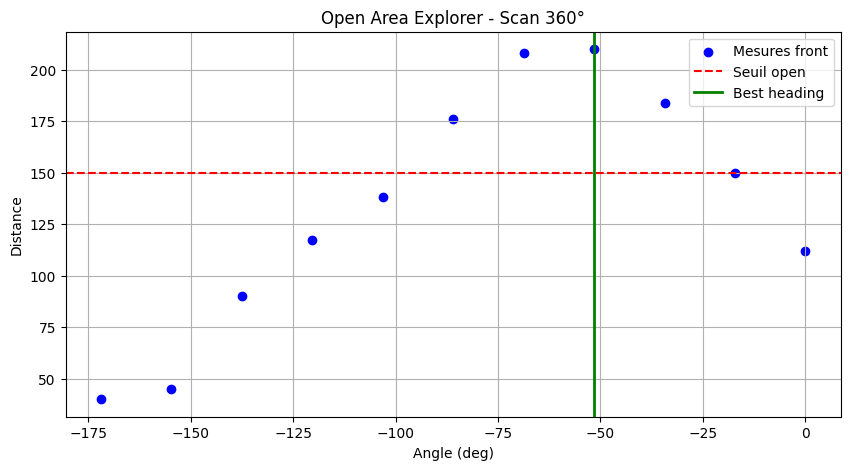

In [276]:
explorer.plot_scan(best_heading=best_heading)

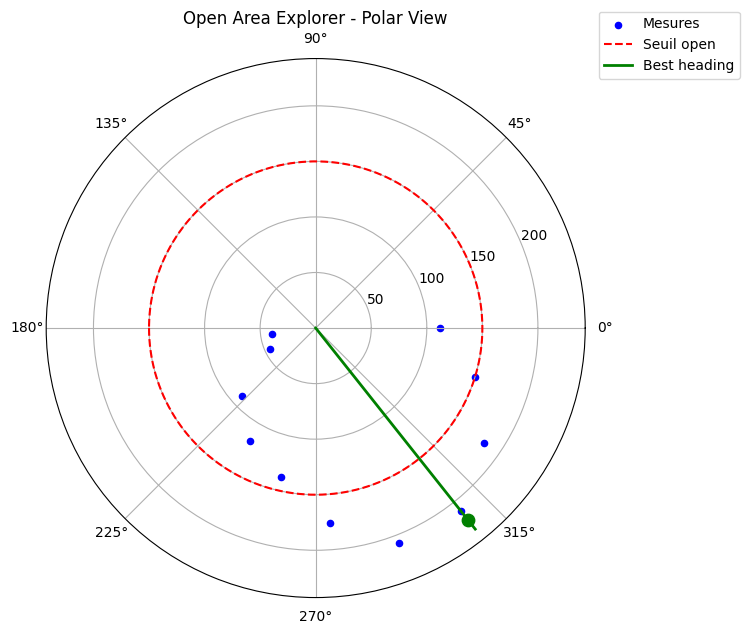

In [277]:
explorer.plot_polar(best_heading=best_heading)

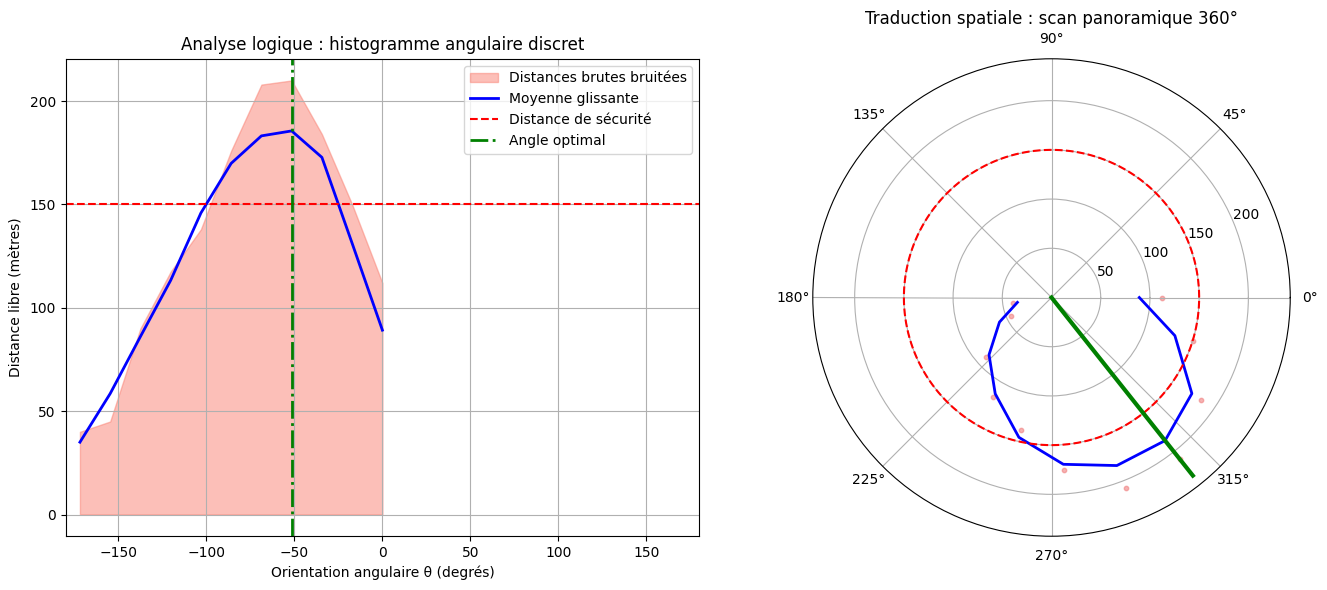

In [278]:
explorer.plot_dual_view(best_heading=best_heading)

In [279]:
explorer = OpenAreaExplorer(
    open_distance_threshold=0.25,
    filter_window_size=2, max_angle_gap_deg=50,
    min_sector_size_deg = 60,
)


explorer.load_data(".\\inputs\\openarea_1778783094.847945.json")

In [280]:
explorer = OpenAreaExplorer(
    open_distance_threshold=0.25,
    filter_window_size=2, max_angle_gap_deg=50,
    min_sector_size_deg = 60,
)


explorer.load_data(".\\inputs\\openarea_1778788864.395361.json")

In [281]:
best_heading = (
    explorer.get_best_heading()
)

print("\n===== RESULT =====")

if best_heading is not None:

    print(
        f"Best Heading (rad): "
        f"{best_heading:.3f}"
    )

    print(
        f"Best Heading (deg): "
        f"{math.degrees(best_heading):.2f}"
    )

else:
    print("No open sector found.")

[(-3.0165241505624127, 1.5), (-2.7482951244137928, 1.5), (-2.5149724863697718, 1.5), (-2.276350839643566, 1.5), (-2.02671232621593, 1.5), (-1.7673986113107825, 1.5), (-1.518655231709234, 1.5), (-1.305235613832024, 1.3599999999999999), (-1.1060252064901046, 1.22), (-0.9398959331406535, 0.7)] width= 2.076628217421759 deg= 118.98203247604229
##################
[(0.985608720622786, 0.295), (1.2694366290423498, 0.43), (1.4557756648306357, 0.44499999999999995), (1.703133418526565, 0.405), (1.9340326433593926, 0.405), (2.2242047409114623, 0.41), (2.4901104151460816, 0.955), (2.7418608605782615, 1.5), (3.021002837574656, 1.5)] width= 2.0353941169518697 deg= 116.61949254709921
##################



Best Sector
[(-3.0165241505624127, 1.5), (-2.7482951244137928, 1.5), (-2.5149724863697718, 1.5), (-2.276350839643566, 1.5), (-2.02671232621593, 1.5), (-1.7673986113107825, 1.5), (-1.518655231709234, 1.5), (-1.305235613832024, 1.3599999999999999), (-1.1060252064901046, 1.22), (-0.9398959331406535, 0.7

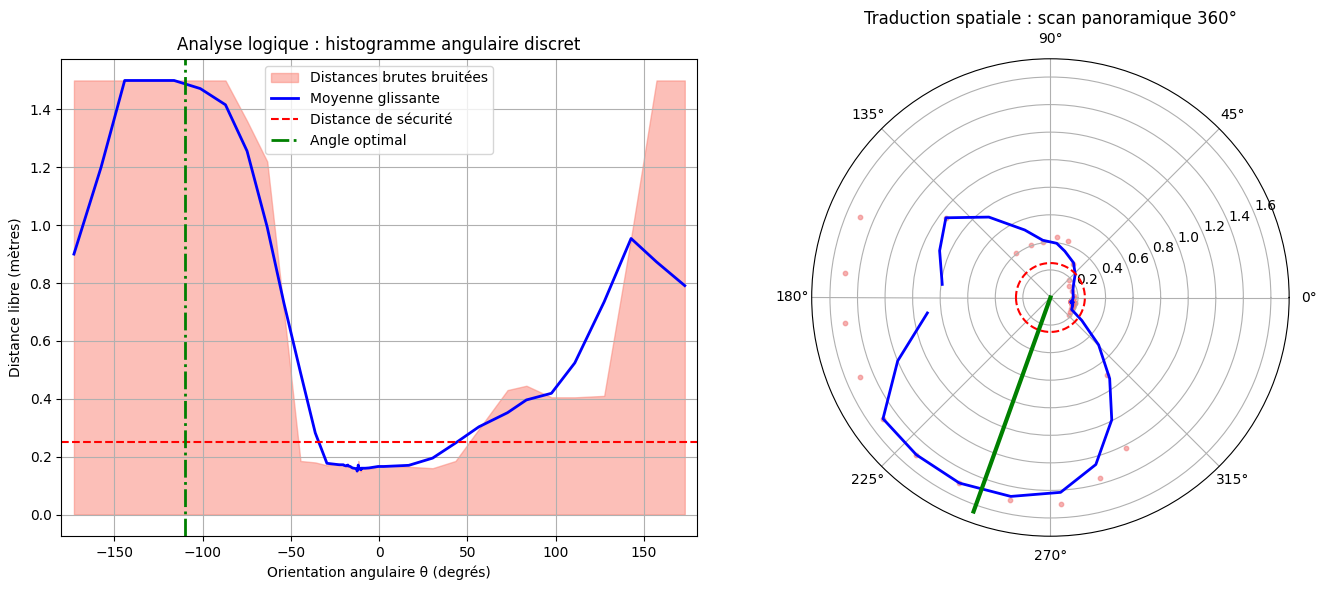

In [282]:
explorer.plot_dual_view(best_heading=best_heading)